# 365 Hotels and Resorts Analysis

First we will load all csv files and then will explore accordingly

In [129]:
import numpy as np

In [ ]:
import pandas as pd
#loading data
dim_date_df = pd.read_csv("dim_date.csv")
dim_hotels_df = pd.read_csv("dim_hotels.csv")
dim_rooms_df = pd.read_csv("dim_rooms.csv")
aggregated_booking_df = pd.read_csv("fact_aggregated_bookings.csv")
fact_booking_df = pd.read_csv("fact_bookings.csv")



In [131]:
#exploring
dim_date_df.head()


,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
1,2022-05-02,May 22,W 19,weekday
2,2022-05-03,May 22,W 19,weekday
3,2022-05-04,May 22,W 19,weekday
4,2022-05-05,May 22,W 19,weekday


In [132]:
dim_date_df.info()
dim_date_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   date      92 non-null     str  
 1   mmm yy    92 non-null     str  
 2   week no   92 non-null     str  
 3   day_type  92 non-null     str  
dtypes: str(4)
memory usage: 3.0 KB


(92, 4)

In [133]:
dim_hotels_df.head()

,property_id,property_name,category,city
0,21558,365 Royal Grands,Luxury,Dubai
1,21559,365 Luxe Exotica,Luxury,Abu Dhabi
2,21560,365 City Haven,Business,Dubai
3,21561,365 Azure Blu,Luxury,Dubai
4,21562,365 Ocean Bay,Luxury,Dubai


In [134]:
dim_hotels_df.info()
dim_hotels_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   property_id    25 non-null     int64
 1   property_name  25 non-null     str  
 2   category       25 non-null     str  
 3   city           25 non-null     str  
dtypes: int64(1), str(3)
memory usage: 932.0 bytes


(25, 4)

In [135]:
dim_rooms_df.head()

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [136]:
dim_rooms_df.info()
dim_rooms_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   room_id     4 non-null      str  
 1   room_class  4 non-null      str  
dtypes: str(2)
memory usage: 196.0 bytes


(4, 2)

In [137]:
aggregated_booking_df.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,21559,2022-05-01,RT1,25,30.0
1,24562,2022-05-01,RT1,28,30.0
2,24563,2022-05-01,RT1,23,30.0
3,22558,2022-05-01,RT1,30,19.0
4,21558,2022-05-01,RT1,18,19.0


In [138]:
aggregated_booking_df.info()
aggregated_booking_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          9200 non-null   int64  
 1   check_in_date        9200 non-null   str    
 2   room_category        9200 non-null   str    
 3   successful_bookings  9200 non-null   int64  
 4   capacity             9198 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 359.5 KB


(9200, 5)

In [139]:
fact_booking_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012221558RT11,21558,2022-04-27,2022-05-01,2022-05-02,-3.0,RT1,Direct Online,1.0,Checked Out,1001,1001
1,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.0,Checked Out,910000,910
3,May012221558RT14,21558,2022-04-28,2022-05-01,2022-05-02,-2.0,RT1,Others,NaN,Cancelled,910,364
4,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.0,Checked Out,1092,1092


In [140]:
fact_booking_df.info()
fact_booking_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134590 non-null  str    
 1   property_id        134590 non-null  int64  
 2   booking_date       134590 non-null  str    
 3   check_in_date      134590 non-null  str    
 4   checkout_date      134590 non-null  str    
 5   no_guests          134587 non-null  float64
 6   room_category      134590 non-null  str    
 7   booking_platform   134590 non-null  str    
 8   ratings_given      56683 non-null   float64
 9   booking_status     134590 non-null  str    
 10  revenue_generated  134590 non-null  int64  
 11  revenue_realized   134590 non-null  int64  
dtypes: float64(2), int64(3), str(7)
memory usage: 12.3 MB


(134590, 12)

##### Cleaning Data 

In [141]:
# Checking the total nulls
dim_date_df.isnull().sum()

date        0
mmm yy      0
week no     0
day_type    0
dtype: int64

In [142]:
dim_hotels_df.isnull().sum()

property_id      0
property_name    0
category         0
city             0
dtype: int64

In [143]:
dim_rooms_df.isnull().sum()

room_id       0
room_class    0
dtype: int64

In [144]:
aggregated_booking_df.isnull().sum()
# we have 2 nulls in capacity column

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

In [145]:
fact_booking_df.isnull().sum()
# we have 77907 nulls in rating given col


booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                3
room_category            0
booking_platform         0
ratings_given        77907
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

In [146]:
fact_booking_df.shape

(134590, 12)

#### Checking Dublicates

In [147]:
dim_date_df.duplicated().sum()

np.int64(0)

In [148]:
dim_hotels_df.duplicated().sum()

np.int64(0)

In [149]:
dim_rooms_df.duplicated().sum()

np.int64(0)

In [150]:
aggregated_booking_df.duplicated().sum()

np.int64(0)

In [151]:
fact_booking_df.duplicated().sum()
# so no duplicates found

np.int64(0)

In [152]:
# as we hade more than 77000 nulls in rating given from fact_booking so we need to investigate that
fact_booking_df["ratings_given"].value_counts(dropna=False)

ratings_given
NaN    77907
5.0    19480
3.0    17561
4.0     9653
2.0     6452
1.0     3537
Name: count, dtype: int64

In [153]:
# here we are using crosstab so that we can find out relation between status of booking and rating given
# here True means rating not given and false means rating given
pd.crosstab(
    fact_booking_df["booking_status"],
    fact_booking_df["ratings_given"].isna()
)
# so from in interpretation we can see that only checkout customers given ratings

ratings_given,False,True
booking_status,,
Cancelled,0,33420
Checked Out,56683,37728
No Show,0,6759


In [154]:
rating_mean = fact_booking_df["ratings_given"].mean()

In [155]:
round(rating_mean,2)

np.float64(3.62)

In [156]:
# here i removed the null with mean of rating for only those who had status = checked out but rating was null
fact_booking_df['ratings_given'] = np.where( (fact_booking_df['ratings_given'].isna() )
                                    & (fact_booking_df['booking_status'] == 'Checked Out'),
                                     round(rating_mean,2),
                                     fact_booking_df['ratings_given'])

In [157]:
fact_booking_df.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                3
room_category            0
booking_platform         0
ratings_given        40179
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

In [158]:
aggregated_booking_df.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

In [159]:
aggregated_booking_df[
    aggregated_booking_df['capacity'].isna()
].head()

,property_id,check_in_date,room_category,successful_bookings,capacity
8,22561,2022-05-01,RT1,22,NaN
14,22562,2022-05-01,RT1,12,NaN


In [160]:
aggregated_booking_df.head(10)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,21559,2022-05-01,RT1,25,30.0
1,24562,2022-05-01,RT1,28,30.0
2,24563,2022-05-01,RT1,23,30.0
3,22558,2022-05-01,RT1,30,19.0
4,21558,2022-05-01,RT1,18,19.0
5,22560,2022-05-01,RT1,28,40.0
6,24558,2022-05-01,RT1,25,40.0
7,24560,2022-05-01,RT1,23,26.0
8,22561,2022-05-01,RT1,22,NaN
9,21560,2022-05-01,RT1,24,34.0


In [161]:
aggregated_booking_df[
    (aggregated_booking_df['property_id'] == 22561) & (aggregated_booking_df['room_category'] =='RT1')
]
# so from here we can see our missing capacity value for property_id 22561 with room_category RT1 was 26 
# as all the rooms of this id have this capacity

,property_id,check_in_date,room_category,successful_bookings,capacity
8,22561,2022-05-01,RT1,22,NaN
109,22561,2022-05-02,RT1,15,26.0
210,22561,2022-05-03,RT1,16,26.0
309,22561,2022-05-04,RT1,15,26.0
409,22561,2022-05-05,RT1,15,26.0
...,...,...,...,...,...
8709,22561,2022-07-27,RT1,14,26.0
8809,22561,2022-07-28,RT1,14,26.0
8909,22561,2022-07-29,RT1,15,26.0
9009,22561,2022-07-30,RT1,20,26.0


In [162]:
aggregated_booking_df['capacity'] = np.where(
    (aggregated_booking_df['property_id'] == 22561) & (aggregated_booking_df['room_category'] =='RT1'),
    26,
    aggregated_booking_df['capacity']
)

In [163]:
aggregated_booking_df[
    aggregated_booking_df['capacity'].isna()
].head()

,property_id,check_in_date,room_category,successful_bookings,capacity
14,22562,2022-05-01,RT1,12,NaN


In [164]:
aggregated_booking_df[
    (aggregated_booking_df['property_id'] == 22562) & (aggregated_booking_df['room_category'] == 'RT1')
]
# so from here we can see all the rooms with property id 22562 and category RT1 has capacity of 20

,property_id,check_in_date,room_category,successful_bookings,capacity
14,22562,2022-05-01,RT1,12,NaN
115,22562,2022-05-02,RT1,9,20.0
216,22562,2022-05-03,RT1,10,20.0
315,22562,2022-05-04,RT1,9,20.0
415,22562,2022-05-05,RT1,8,20.0
...,...,...,...,...,...
8715,22562,2022-07-27,RT1,8,20.0
8815,22562,2022-07-28,RT1,9,20.0
8915,22562,2022-07-29,RT1,7,20.0
9015,22562,2022-07-30,RT1,10,20.0


In [165]:
aggregated_booking_df['capacity'] = np.where(
    (aggregated_booking_df['property_id'] == 22562) & (aggregated_booking_df['room_category'] == 'RT1'),
    20,
    aggregated_booking_df['capacity']
)

In [166]:
aggregated_booking_df[
    aggregated_booking_df['capacity'].isna()
].head()

,property_id,check_in_date,room_category,successful_bookings,capacity


In [167]:
fact_booking_df[['no_guests']]

,no_guests
0,-3.0
1,2.0
2,2.0
3,-2.0
4,4.0
...,...
134585,1.0
134586,-4.0
134587,1.0
134588,2.0


In [168]:
fact_booking_df.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,94411.000000,1.345900e+05,134590.000000
mean,23061.113493,2.036170,3.619402,1.537806e+03,1269.608515
std,1093.055847,1.034885,0.956938,9.303604e+03,692.815146
min,21558.000000,-17.000000,1.000000,6.500000e+02,260.000000
25%,22558.000000,1.000000,3.000000,9.900000e+02,760.000000
50%,22564.000000,2.000000,3.620000,1.350000e+03,1170.000000
75%,23563.000000,2.000000,4.000000,1.800000e+03,1530.000000
max,24563.000000,6.000000,5.000000,2.856000e+06,4522.000000


In [169]:
fact_booking_df[fact_booking_df['no_guests']<1]['no_guests'].count()

np.int64(9)

In [170]:
fact_booking_df.shape

(134590, 12)

In [171]:
fact_booking_df[fact_booking_df['no_guests']<1]['no_guests'].value_counts()

no_guests
-4.0     2
-3.0     1
-2.0     1
-10.0    1
-12.0    1
-6.0     1
-17.0    1
-1.0     1
Name: count, dtype: int64

#### As there are just 9 rows with number of guests <1 out of 134590 and its not possible -4 will be +4 or -17 will be +17 so we can drop these 9 rows as they are not much and will not much effect our analysis

In [172]:
# Droping them
invalid_rows = fact_booking_df[fact_booking_df['no_guests']<1].index

In [173]:
fact_booking_df.drop(index=invalid_rows,inplace=True)

In [174]:
fact_booking_df.shape

(134581, 12)

In [175]:
#checking no_guest invalid rows
fact_booking_df[fact_booking_df['no_guests']<1]['no_guests'].count()

np.int64(0)

In [176]:
fact_booking_df['revenue_generated'].describe()

count    1.345810e+05
mean     1.537805e+03
std      9.303912e+03
min      6.500000e+02
25%      9.900000e+02
50%      1.350000e+03
75%      1.800000e+03
max      2.856000e+06
Name: revenue_generated, dtype: float64

In [177]:
fact_booking_df['revenue_generated'].head(100)

1         910
2      910000
4        1092
5         910
6         910
        ...  
97       1530
98       1530
99       1530
100      1836
101      1530
Name: revenue_generated, Length: 100, dtype: int64

In [178]:
fact_booking_df['revenue_generated'].tail(100)

134489     975
134490     975
134491     975
134492     975
134493     975
          ... 
134584    3230
134585    3230
134587    3230
134588    3230
134589    3230
Name: revenue_generated, Length: 100, dtype: int64

In [179]:
fact_booking_df.info()

<class 'pandas.DataFrame'>
Index: 134581 entries, 1 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134581 non-null  str    
 1   property_id        134581 non-null  int64  
 2   booking_date       134581 non-null  str    
 3   check_in_date      134581 non-null  str    
 4   checkout_date      134581 non-null  str    
 5   no_guests          134578 non-null  float64
 6   room_category      134581 non-null  str    
 7   booking_platform   134581 non-null  str    
 8   ratings_given      94406 non-null   float64
 9   booking_status     134581 non-null  str    
 10  revenue_generated  134581 non-null  int64  
 11  revenue_realized   134581 non-null  int64  
dtypes: float64(2), int64(3), str(7)
memory usage: 13.3 MB


In [180]:
fact_booking_df['revenue_generated'].mean()


np.float64(1537.8054480201515)

### so mean is 1537.8 so we will figure out the issue with revenue genrated > mean

In [181]:
fact_booking_df[fact_booking_df['revenue_generated']> 1537.8]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.00,Checked Out,910000,910
39,May012221558RT31,21558,2022-04-27,2022-05-01,2022-05-03,3.0,RT3,Others,3.00,Checked Out,1848,1848
40,May012221558RT32,21558,2022-04-24,2022-05-01,2022-05-06,4.0,RT3,DeBookkarus,3.62,Checked Out,2016,2016
41,May012221558RT33,21558,2022-04-26,2022-05-01,2022-05-07,2.0,RT3,DeBookkarus,3.62,Checked Out,1680,1680
42,May012221558RT34,21558,2022-04-29,2022-05-01,2022-05-02,1.0,RT3,Others,5.00,Checked Out,1680,1680
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312222564RT45,22564,2022-07-30,2022-07-31,2022-08-01,2.0,RT4,Others,2.00,Checked Out,3230,3230
134585,Jul312222564RT46,22564,2022-07-29,2022-07-31,2022-08-03,1.0,RT4,DeBookkarus,2.00,Checked Out,3230,3230
134587,Jul312222564RT48,22564,2022-07-30,2022-07-31,2022-08-02,1.0,RT4,Eventica Travels,NaN,Cancelled,3230,1292
134588,Jul312222564RT49,22564,2022-07-29,2022-07-31,2022-08-01,2.0,RT4,Bookings_Com,2.00,Checked Out,3230,3230


In [182]:
fact_booking_df[fact_booking_df['revenue_generated']> 1537.8]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.00,Checked Out,910000,910
39,May012221558RT31,21558,2022-04-27,2022-05-01,2022-05-03,3.0,RT3,Others,3.00,Checked Out,1848,1848
40,May012221558RT32,21558,2022-04-24,2022-05-01,2022-05-06,4.0,RT3,DeBookkarus,3.62,Checked Out,2016,2016
41,May012221558RT33,21558,2022-04-26,2022-05-01,2022-05-07,2.0,RT3,DeBookkarus,3.62,Checked Out,1680,1680
42,May012221558RT34,21558,2022-04-29,2022-05-01,2022-05-02,1.0,RT3,Others,5.00,Checked Out,1680,1680
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312222564RT45,22564,2022-07-30,2022-07-31,2022-08-01,2.0,RT4,Others,2.00,Checked Out,3230,3230
134585,Jul312222564RT46,22564,2022-07-29,2022-07-31,2022-08-03,1.0,RT4,DeBookkarus,2.00,Checked Out,3230,3230
134587,Jul312222564RT48,22564,2022-07-30,2022-07-31,2022-08-02,1.0,RT4,Eventica Travels,NaN,Cancelled,3230,1292
134588,Jul312222564RT49,22564,2022-07-29,2022-07-31,2022-08-01,2.0,RT4,Bookings_Com,2.00,Checked Out,3230,3230


In [183]:
# to investigate the suspicious values first we will fine the most extreme value in revenue genrated
fact_booking_df['revenue_generated'].sort_values(ascending=False).head(5)

111       2856000
315       1260000
129176    1000000
2          910000
562        200000
Name: revenue_generated, dtype: int64

In [184]:
fact_booking_df[fact_booking_df['revenue_generated'] ==  2856000]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
111,May012221559RT32,21559,2022-04-29,2022-05-01,2022-05-02,6.0,RT3,Direct Online,3.62,Checked Out,2856000,2856


In [185]:
fact_booking_df[fact_booking_df.index==111]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
111,May012221559RT32,21559,2022-04-29,2022-05-01,2022-05-02,6.0,RT3,Direct Online,3.62,Checked Out,2856000,2856


In [186]:
fact_booking_df.nlargest(20, 'revenue_generated')

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
111,May012221559RT32,21559,2022-04-29,2022-05-01,2022-05-02,6.0,RT3,Direct Online,3.62,Checked Out,2856000,2856
315,May012221562RT22,21562,2022-04-28,2022-05-01,2022-05-04,2.0,RT2,Direct Offline,3.00,Checked Out,1260000,1260
129176,Jul282221562RT26,21562,2022-07-21,2022-07-28,2022-07-29,2.0,RT2,Direct Online,3.00,Checked Out,1000000,1260
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.00,Checked Out,910000,910
562,May012222559RT118,22559,2022-04-26,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,200000,442
139,May012221559RT43,21559,2022-05-01,2022-05-01,2022-05-02,6.0,RT4,Eventica Travels,3.00,Checked Out,4522,4522
715,May012222560RT46,22560,2022-04-28,2022-05-01,2022-05-02,6.0,RT4,DeBookkarus,3.00,Checked Out,4522,4522
719,May012222560RT410,22560,2022-05-01,2022-05-01,2022-05-04,6.0,RT4,Others,2.00,Checked Out,4522,4522
2107,May022221559RT47,21559,2022-04-28,2022-05-02,2022-05-04,6.0,RT4,Bookings_Com,3.62,Checked Out,4522,4522
2381,May022222558RT42,22558,2022-04-25,2022-05-02,2022-05-08,6.0,RT4,DeBookkarus,3.00,Checked Out,4522,4522


In [187]:
fact_booking_df[
    (fact_booking_df['room_category'] == 'RT2') &
    (fact_booking_df['no_guests'] == 2)
][[
    'no_guests',
    'room_category',
    'check_in_date',
    'checkout_date',
    'revenue_generated',
    'revenue_realized'
]].head(20)

,no_guests,room_category,check_in_date,checkout_date,revenue_generated,revenue_realized
18,2.0,RT2,2022-05-01,2022-05-06,1260,1260
19,2.0,RT2,2022-05-01,2022-05-03,1260,1260
23,2.0,RT2,2022-05-01,2022-05-02,1260,1260
25,2.0,RT2,2022-05-01,2022-05-02,1260,1260
26,2.0,RT2,2022-05-01,2022-05-02,1260,1260
27,2.0,RT2,2022-05-01,2022-05-02,1260,1260
28,2.0,RT2,2022-05-01,2022-05-07,1260,504
29,2.0,RT2,2022-05-01,2022-05-02,1260,1260
32,2.0,RT2,2022-05-01,2022-05-04,1260,1260
37,2.0,RT2,2022-05-01,2022-05-04,1260,1260


In [188]:
fact_booking_df[fact_booking_df['revenue_generated']>1000000]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
111,May012221559RT32,21559,2022-04-29,2022-05-01,2022-05-02,6.0,RT3,Direct Online,3.62,Checked Out,2856000,2856
315,May012221562RT22,21562,2022-04-28,2022-05-01,2022-05-04,2.0,RT2,Direct Offline,3.00,Checked Out,1260000,1260


In [189]:
fact_booking_df['check_in_date'] = pd.to_datetime(
    fact_booking_df['check_in_date']
)
fact_booking_df['checkout_date'] = pd.to_datetime(
    fact_booking_df['checkout_date']
)

In [190]:
# indentify the 200,000 suspicous value
fact_booking_df[(fact_booking_df['booking_status']=='Cancelled') 
                & (fact_booking_df['no_guests'] == 2)
                & (fact_booking_df['room_category'] == 'RT1')
                & ((fact_booking_df['checkout_date'] - fact_booking_df['check_in_date']).dt.days == 1)
                ]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364
62,May012221559RT113,21559,2022-04-26,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,1105,442
236,May012221561RT113,21561,2022-04-26,2022-05-01,2022-05-02,2.0,RT1,DeBookkarus,NaN,Cancelled,910,364
469,May012222558RT11,22558,2022-04-11,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,1105,442
551,May012222559RT17,22559,2022-05-01,2022-05-01,2022-05-02,2.0,RT1,DeBookkarus,NaN,Cancelled,1105,442
...,...,...,...,...,...,...,...,...,...,...,...,...
134146,Jul312224558RT14,24558,2022-07-27,2022-07-31,2022-08-01,2.0,RT1,Others,NaN,Cancelled,975,390
134203,Jul312224559RT16,24559,2022-07-26,2022-07-31,2022-08-01,2.0,RT1,Others,NaN,Cancelled,975,390
134334,Jul312224561RT12,24561,2022-07-26,2022-07-31,2022-08-01,2.0,RT1,Others,NaN,Cancelled,975,390
134414,Jul312224562RT115,24562,2022-07-29,2022-07-31,2022-08-01,2.0,RT1,Direct Online,NaN,Cancelled,975,390


In [191]:
suspicious_revenue = fact_booking_df[
    fact_booking_df['revenue_generated'].isin(
        [2856000, 1260000, 1000000, 910000, 200000]
    )
]

suspicious_revenue.shape

(5, 12)

In [192]:
fact_booking_df['revenue_generated'] = np.where(
    fact_booking_df['revenue_generated'] == 2856000,
    2856,
    fact_booking_df['revenue_generated']
)

fact_booking_df['revenue_generated'] = np.where(
    fact_booking_df['revenue_generated'] == 1260000,
    1260,
    fact_booking_df['revenue_generated']
)

fact_booking_df['revenue_generated'] = np.where(
    fact_booking_df['revenue_generated'] == 910000,
    910,
    fact_booking_df['revenue_generated']
)

In [193]:
fact_booking_df[
    fact_booking_df['revenue_generated'].isin([2856, 1260, 910])
][['revenue_generated', 'revenue_realized']]

,revenue_generated,revenue_realized
1,910,364
2,910,910
5,910,910
6,910,364
7,910,910
...,...,...
133302,1260,1260
133444,2856,2856
133520,2856,1142
133625,2856,1142


In [194]:
# droping two rows as we havnt founded  any clue weather it was a typing error or anything else 
rows_to_drop = fact_booking_df[
    fact_booking_df['revenue_generated'].isin([1000000, 200000])
].index

len(rows_to_drop)

2

In [195]:
fact_booking_df.drop(index=rows_to_drop, inplace=True)

#### Now working on Over-capacity rows cleaning 

In [196]:
# first checking the over capacity rows 
# shift to new dataframe which is aggregated_booking_df
aggregated_booking_df.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,21559,2022-05-01,RT1,25,30.0
1,24562,2022-05-01,RT1,28,30.0
2,24563,2022-05-01,RT1,23,30.0
3,22558,2022-05-01,RT1,30,19.0
4,21558,2022-05-01,RT1,18,19.0


In [197]:
aggregated_booking_df[aggregated_booking_df['successful_bookings']>aggregated_booking_df['capacity']]


,property_id,check_in_date,room_category,successful_bookings,capacity
3,22558,2022-05-01,RT1,30,19.0
12,21563,2022-05-01,RT1,100,41.0
4136,24558,2022-06-11,RT2,50,39.0
6209,24560,2022-07-02,RT1,123,26.0
8522,24559,2022-07-25,RT1,35,24.0
9194,23563,2022-07-31,RT4,20,18.0


In [198]:
aggregated_booking_df[aggregated_booking_df['successful_bookings']>aggregated_booking_df['capacity']].shape[0]

6

In [199]:
# so we have total 6 bookings greater than the capacity
aggregated_booking_df.shape[0]



9200

In [200]:
percentage_of_overcapcity = (aggregated_booking_df[aggregated_booking_df['successful_bookings']>aggregated_booking_df['capacity']].shape[0])/(aggregated_booking_df.shape[0])*100

In [201]:
print(percentage_of_overcapcity)

0.06521739130434784


In [202]:
overcapacity_rows_to_drop = aggregated_booking_df[
    aggregated_booking_df['successful_bookings']>aggregated_booking_df['capacity']
].index
overcapacity_rows_to_drop.shape[0]



6

In [203]:
aggregated_booking_df.drop(index=overcapacity_rows_to_drop, inplace=True)

In [204]:
aggregated_booking_df.shape[0]

9194

In [205]:
aggregated_booking_df[aggregated_booking_df['successful_bookings']>aggregated_booking_df['capacity']].shape[0]

0

In [206]:
aggregated_booking_df.info()

<class 'pandas.DataFrame'>
Index: 9194 entries, 0 to 9199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          9194 non-null   int64  
 1   check_in_date        9194 non-null   str    
 2   room_category        9194 non-null   str    
 3   successful_bookings  9194 non-null   int64  
 4   capacity             9194 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 431.0 KB


## 4. Core Metric Development

In [207]:
#Occupancy % = successful_bookings / capacity. This is the single most important number in
#hospitality and everything else sits downstream of it.
aggregated_booking_df['occupancy'] =( (
    aggregated_booking_df['successful_bookings'] /
    aggregated_booking_df['capacity']
) * 100).round(2)

In [208]:
#created the occupancy col for resuing it as mentioned in the pdf 
aggregated_booking_df.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy
0,21559,2022-05-01,RT1,25,30.0,83.33
1,24562,2022-05-01,RT1,28,30.0,93.33
2,24563,2022-05-01,RT1,23,30.0,76.67
4,21558,2022-05-01,RT1,18,19.0,94.74
5,22560,2022-05-01,RT1,28,40.0,70.00


In [209]:
fact_booking_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.0,Checked Out,910,910
4,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.0,Checked Out,1092,1092
5,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.0,Checked Out,910,910
6,May012221558RT17,21558,2022-04-28,2022-05-01,2022-05-06,2.0,RT1,Others,NaN,Cancelled,910,364


In [210]:
completed_stays = fact_booking_df[fact_booking_df['booking_status'] == 'Checked Out'].shape[0]
print(completed_stays)

94405


In [211]:
adr = fact_booking_df[
    fact_booking_df['booking_status'] == 'Checked Out'
]['revenue_realized'].sum() / completed_stays
adr=round(adr,2)
print(adr)

1492.52


In [212]:
# now for RevPAR (Revenue Per Available Room)
aggregated_booking_df.head()


,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy
0,21559,2022-05-01,RT1,25,30.0,83.33
1,24562,2022-05-01,RT1,28,30.0,93.33
2,24563,2022-05-01,RT1,23,30.0,76.67
4,21558,2022-05-01,RT1,18,19.0,94.74
5,22560,2022-05-01,RT1,28,40.0,70.00


In [213]:
aggregated_booking_df['RevPAR'] =round(adr * (aggregated_booking_df['occupancy']/100),2)
aggregated_booking_df.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR
0,21559,2022-05-01,RT1,25,30.0,83.33,1243.72
1,24562,2022-05-01,RT1,28,30.0,93.33,1392.97
2,24563,2022-05-01,RT1,23,30.0,76.67,1144.32
4,21558,2022-05-01,RT1,18,19.0,94.74,1414.01
5,22560,2022-05-01,RT1,28,40.0,70.00,1044.76


In [214]:
# for Realization %
fact_booking_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.0,Checked Out,910,910
4,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.0,Checked Out,1092,1092
5,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.0,Checked Out,910,910
6,May012221558RT17,21558,2022-04-28,2022-05-01,2022-05-06,2.0,RT1,Others,NaN,Cancelled,910,364


In [215]:
fact_booking_df['Realization'] = fact_booking_df['revenue_realized'] / fact_booking_df['revenue_generated'] * 100
fact_booking_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,Realization
1,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364,40.0
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.0,Checked Out,910,910,100.0
4,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.0,Checked Out,1092,1092,100.0
5,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.0,Checked Out,910,910,100.0
6,May012221558RT17,21558,2022-04-28,2022-05-01,2022-05-06,2.0,RT1,Others,NaN,Cancelled,910,364,40.0


In [216]:
realization_by_status = fact_booking_df.groupby(
    'booking_status'
)['Realization'].mean()

realization_by_status

booking_status
Cancelled       39.998886
Checked Out    100.000000
No Show        100.000000
Name: Realization, dtype: float64

### Checked-out and no-show bookings have 100% realization, while cancelled bookings realize approximately 40% of their generated revenue.

In [217]:
# for Length of Stay and i already converty the required col to date
fact_booking_df['length_of_stay'] = fact_booking_df['checkout_date'] - fact_booking_df['check_in_date']
fact_booking_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,Realization,length_of_stay
1,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,1 days
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.0,Checked Out,910,910,100.0,3 days
4,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.0,Checked Out,1092,1092,100.0,1 days
5,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.0,Checked Out,910,910,100.0,2 days
6,May012221558RT17,21558,2022-04-28,2022-05-01,2022-05-06,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,5 days


## 5. Required Analysis

In [218]:
fact_booking_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,Realization,length_of_stay
1,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,1 days
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.0,Checked Out,910,910,100.0,3 days
4,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.0,Checked Out,1092,1092,100.0,1 days
5,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.0,Checked Out,910,910,100.0,2 days
6,May012221558RT17,21558,2022-04-28,2022-05-01,2022-05-06,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,5 days


In [219]:
aggregated_booking_df.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR
0,21559,2022-05-01,RT1,25,30.0,83.33,1243.72
1,24562,2022-05-01,RT1,28,30.0,93.33,1392.97
2,24563,2022-05-01,RT1,23,30.0,76.67,1144.32
4,21558,2022-05-01,RT1,18,19.0,94.74,1414.01
5,22560,2022-05-01,RT1,28,40.0,70.00,1044.76


In [220]:
dim_hotels_df.head()

,property_id,property_name,category,city
0,21558,365 Royal Grands,Luxury,Dubai
1,21559,365 Luxe Exotica,Luxury,Abu Dhabi
2,21560,365 City Haven,Business,Dubai
3,21561,365 Azure Blu,Luxury,Dubai
4,21562,365 Ocean Bay,Luxury,Dubai


In [221]:
# first we will merge both dataframes on property_id 
merged_df = pd.merge(dim_hotels_df, aggregated_booking_df, on="property_id")
merged_df.head()

,property_id,property_name,category,city,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR
0,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT1,18,19.0,94.74,1414.01
1,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT2,21,22.0,95.45,1424.61
2,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT3,8,8.0,100.00,1492.52
3,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT4,3,3.0,100.00,1492.52
4,21558,365 Royal Grands,Luxury,Dubai,2022-05-02,RT1,12,19.0,63.16,942.68


In [222]:
# we are using group by on city and then calculating the avg of occupancy
Avg_city_occupancy = merged_df.groupby('city')['occupancy'].mean()
round(Avg_city_occupancy,2)

city
Abu Dhabi         57.91
Dubai             61.51
Ras Al Khaimah    56.33
Sharjah           58.12
Name: occupancy, dtype: float64

##### here we have calculated the average occupancy by city like Dubai have average occupancy of 61.51

### Average occupancy by room class, and whether the pattern holds across all four cities or one city breaks it.

In [223]:
merged_df.head()

,property_id,property_name,category,city,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR
0,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT1,18,19.0,94.74,1414.01
1,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT2,21,22.0,95.45,1424.61
2,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT3,8,8.0,100.00,1492.52
3,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT4,3,3.0,100.00,1492.52
4,21558,365 Royal Grands,Luxury,Dubai,2022-05-02,RT1,12,19.0,63.16,942.68


In [224]:
avg_room_class_occu = merged_df.groupby('room_category')['occupancy'].mean()
avg_room_class_occu

room_category
RT1    57.893397
RT2    58.009756
RT3    58.028213
RT4    59.277925
Name: occupancy, dtype: float64

In [225]:
# now working on 2nd part of the question 
city_pattern = merged_df.groupby(['room_category','city'])['occupancy'].mean()
round(city_pattern,2)

room_category  city          
RT1            Abu Dhabi         57.46
               Dubai             60.92
               Ras Al Khaimah    56.00
               Sharjah           57.83
RT2            Abu Dhabi         57.56
               Dubai             60.71
               Ras Al Khaimah    56.07
               Sharjah           58.29
RT3            Abu Dhabi         57.65
               Dubai             61.15
               Ras Al Khaimah    55.82
               Sharjah           58.13
RT4            Abu Dhabi         58.97
               Dubai             63.25
               Ras Al Khaimah    57.44
               Sharjah           58.22
Name: occupancy, dtype: float64

### RT4 consistenty record the highest occupancy across all four cities which is showing stronger demand for this room class rather than the result being driven by a single city.

### Occupancy on weekdays versus weekends. The gap is large; state what it implies about who these hotels are actually serving

In [226]:
merged_df.head()

,property_id,property_name,category,city,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR
0,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT1,18,19.0,94.74,1414.01
1,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT2,21,22.0,95.45,1424.61
2,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT3,8,8.0,100.00,1492.52
3,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT4,3,3.0,100.00,1492.52
4,21558,365 Royal Grands,Luxury,Dubai,2022-05-02,RT1,12,19.0,63.16,942.68


In [227]:
merged_df['check_in_date'] = pd.to_datetime(merged_df['check_in_date'])

In [228]:
# in this we are using dt.day_name() which is converting our dates in day names and then filtering through isin function 
merged_df['day_type'] = np.where(
    merged_df['check_in_date'].dt.day_name().isin(['Saturday','Sunday']),
    'weekend',
    'weekday'
)

In [229]:
merged_df.head()

,property_id,property_name,category,city,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR,day_type
0,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT1,18,19.0,94.74,1414.01,weekend
1,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT2,21,22.0,95.45,1424.61,weekend
2,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT3,8,8.0,100.00,1492.52,weekend
3,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT4,3,3.0,100.00,1492.52,weekend
4,21558,365 Royal Grands,Luxury,Dubai,2022-05-02,RT1,12,19.0,63.16,942.68,weekday


In [230]:
merged_df['day_type'].value_counts()

day_type
weekday    6499
weekend    2695
Name: count, dtype: int64

In [231]:
weekend_weekday_occupancy = merged_df.groupby(['city','day_type'])['occupancy'].mean()
print(weekend_weekday_occupancy)

city            day_type
Abu Dhabi       weekday     51.562856
                weekend     73.215064
Dubai           weekday     54.646508
                weekend     78.054805
Ras Al Khaimah  weekday     50.062893
                weekend     71.462601
Sharjah         weekday     51.513321
                weekend     74.051777
Name: occupancy, dtype: float64


#### so we can clearly see on weekend occupany is relativly higher than on weekdays 

### Occupancy by week across the 12 weeks, with a clear statement on whether the trend is up, down or flat.

In [232]:
merged_df['week'] = merged_df['check_in_date'].dt.isocalendar().week

In [233]:
merged_df.head()

,property_id,property_name,category,city,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR,day_type,week
0,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT1,18,19.0,94.74,1414.01,weekend,17
1,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT2,21,22.0,95.45,1424.61,weekend,17
2,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT3,8,8.0,100.00,1492.52,weekend,17
3,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT4,3,3.0,100.00,1492.52,weekend,17
4,21558,365 Royal Grands,Luxury,Dubai,2022-05-02,RT1,12,19.0,63.16,942.68,weekday,18


In [234]:
weekly_occupancy = merged_df.groupby('week')['occupancy'].mean()

weekly_occupancy

week
17    79.409490
18    62.424529
19    60.100314
20    53.463371
21    60.490471
22    53.656843
23    62.934263
24    60.179429
25    53.367386
26    62.379227
27    62.355500
28    60.637529
29    51.395586
30    51.585358
Name: occupancy, dtype: float64

### according to our cal we can see the downward trend we can clearly see week 17 = 79.4 and week 30 = 51.5

## Revenue

### Total realized revenue by hotel category, Luxury versus Business.

In [235]:
fact_booking_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,Realization,length_of_stay
1,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,1 days
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.0,Checked Out,910,910,100.0,3 days
4,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.0,Checked Out,1092,1092,100.0,1 days
5,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.0,Checked Out,910,910,100.0,2 days
6,May012221558RT17,21558,2022-04-28,2022-05-01,2022-05-06,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,5 days


In [236]:
dim_hotels_df.head()

,property_id,property_name,category,city
0,21558,365 Royal Grands,Luxury,Dubai
1,21559,365 Luxe Exotica,Luxury,Abu Dhabi
2,21560,365 City Haven,Business,Dubai
3,21561,365 Azure Blu,Luxury,Dubai
4,21562,365 Ocean Bay,Luxury,Dubai


In [238]:
# first we will be merging both the dataframes fact_booking_df and dim_hotels_df on property_id
booking_hotel_df = pd.merge(fact_booking_df,dim_hotels_df, on = 'property_id')


In [239]:
booking_hotel_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,Realization,length_of_stay,property_name,category,city
0,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,1 days,365 Royal Grands,Luxury,Dubai
1,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.0,Checked Out,910,910,100.0,3 days,365 Royal Grands,Luxury,Dubai
2,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.0,Checked Out,1092,1092,100.0,1 days,365 Royal Grands,Luxury,Dubai
3,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.0,Checked Out,910,910,100.0,2 days,365 Royal Grands,Luxury,Dubai
4,May012221558RT17,21558,2022-04-28,2022-05-01,2022-05-06,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,5 days,365 Royal Grands,Luxury,Dubai


In [240]:
total_realized_by_cat = booking_hotel_df.groupby('category')['revenue_realized'].sum()
total_realized_by_cat

category
Business     65596552
Luxury      105266409
Name: revenue_realized, dtype: int64

### so we can see luxruy hotel category is genrating more revenue than Business category

### RevPAR by property, ranked, naming the top three and bottom three.

In [241]:
merged_df.head()

,property_id,property_name,category,city,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR,day_type,week
0,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT1,18,19.0,94.74,1414.01,weekend,17
1,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT2,21,22.0,95.45,1424.61,weekend,17
2,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT3,8,8.0,100.00,1492.52,weekend,17
3,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT4,3,3.0,100.00,1492.52,weekend,17
4,21558,365 Royal Grands,Luxury,Dubai,2022-05-02,RT1,12,19.0,63.16,942.68,weekday,18


In [242]:
RevPar_by_property = merged_df.groupby('property_id')['RevPAR'].mean()
RevPar_by_property

property_id
21558    1010.410815
21559     984.704565
21560     799.588832
21561     981.921658
21562     808.872527
21563     989.445504
22558     804.561608
22559     988.095299
22560     790.110571
22561    1018.994565
22562     678.699103
22563     985.204429
22564     664.264511
23558     798.161359
23559     667.432255
23560     990.684701
23561     974.463614
23562     983.290353
23563     790.531689
24558     669.600300
24559     813.040463
24560     979.501662
24561     793.987853
24562     984.388967
24563     803.947799
Name: RevPAR, dtype: float64

In [244]:
ranked_RevPar = RevPar_by_property.sort_values(ascending=False)
ranked_RevPar

property_id
22561    1018.994565
21558    1010.410815
23560     990.684701
21563     989.445504
22559     988.095299
22563     985.204429
21559     984.704565
24562     984.388967
23562     983.290353
21561     981.921658
24560     979.501662
23561     974.463614
24559     813.040463
21562     808.872527
22558     804.561608
24563     803.947799
21560     799.588832
23558     798.161359
24561     793.987853
23563     790.531689
22560     790.110571
22562     678.699103
24558     669.600300
23559     667.432255
22564     664.264511
Name: RevPAR, dtype: float64

In [245]:
Top_3_RevPar = ranked_RevPar.head(3)
Top_3_RevPar

property_id
22561    1018.994565
21558    1010.410815
23560     990.684701
Name: RevPAR, dtype: float64

In [246]:
bottom_3_RevPar = ranked_RevPar.tail(3)
bottom_3_RevPar

property_id
24558    669.600300
23559    667.432255
22564    664.264511
Name: RevPAR, dtype: float64

### A comparison of the revenue ranking against the occupancy ranking, flagging any property that is high occupancy but low RevPAR and explaining what is happening there.

In [247]:
merged_df.head()

,property_id,property_name,category,city,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR,day_type,week
0,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT1,18,19.0,94.74,1414.01,weekend,17
1,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT2,21,22.0,95.45,1424.61,weekend,17
2,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT3,8,8.0,100.00,1492.52,weekend,17
3,21558,365 Royal Grands,Luxury,Dubai,2022-05-01,RT4,3,3.0,100.00,1492.52,weekend,17
4,21558,365 Royal Grands,Luxury,Dubai,2022-05-02,RT1,12,19.0,63.16,942.68,weekday,18


In [248]:
fact_booking_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,Realization,length_of_stay
1,May012221558RT12,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,1 days
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.0,Checked Out,910,910,100.0,3 days
4,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.0,Checked Out,1092,1092,100.0,1 days
5,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.0,Checked Out,910,910,100.0,2 days
6,May012221558RT17,21558,2022-04-28,2022-05-01,2022-05-06,2.0,RT1,Others,NaN,Cancelled,910,364,40.0,5 days


In [249]:
revnue_by_property = fact_booking_df.groupby('property_id')['revenue_realized'].sum()
revnue_by_property

property_id
21558     3604723
21559    11844871
21560     5493207
21561     5793293
21562     5642444
21563     8913592
22558     7473087
22559     9399255
22560     8799602
22561     7391859
22562     5191431
22563    10151080
22564     6608656
23558     4624651
23559     4782312
23560     6100720
23561     5603685
23562     6922685
23563     4483878
24558     5449342
24559     6002281
24560     8186250
24561     7296245
24562     8244245
24563     6859567
Name: revenue_realized, dtype: int64

In [252]:
Occupancy_by_property = merged_df.groupby('property_id')['occupancy'].mean()
Occupancy_by_property

property_id
21558    67.698370
21559    65.976005
21560    53.573071
21561    65.789538
21562    54.195109
21563    66.293624
22558    53.906267
22559    66.203152
22560    52.938016
22561    68.273424
22562    45.473342
22563    66.009484
22564    44.506304
23558    53.477446
23559    44.718478
23560    66.376685
23561    65.289864
23562    65.881196
23563    52.966240
24558    44.863787
24559    54.474387
24560    65.627384
24561    53.197799
24562    65.954810
24563    53.865136
Name: occupancy, dtype: float64

In [254]:
RevPAR_by_property = merged_df.groupby('property_id')['RevPAR'].mean()
RevPar_by_property

property_id
21558    1010.410815
21559     984.704565
21560     799.588832
21561     981.921658
21562     808.872527
21563     989.445504
22558     804.561608
22559     988.095299
22560     790.110571
22561    1018.994565
22562     678.699103
22563     985.204429
22564     664.264511
23558     798.161359
23559     667.432255
23560     990.684701
23561     974.463614
23562     983.290353
23563     790.531689
24558     669.600300
24559     813.040463
24560     979.501662
24561     793.987853
24562     984.388967
24563     803.947799
Name: RevPAR, dtype: float64

In [257]:
# now we will be ranking for the comaprison
revnue_by_property.sort_values(ascending=False)

property_id
21559    11844871
22563    10151080
22559     9399255
21563     8913592
22560     8799602
24562     8244245
24560     8186250
22558     7473087
22561     7391859
24561     7296245
23562     6922685
24563     6859567
22564     6608656
23560     6100720
24559     6002281
21561     5793293
21562     5642444
23561     5603685
21560     5493207
24558     5449342
22562     5191431
23559     4782312
23558     4624651
23563     4483878
21558     3604723
Name: revenue_realized, dtype: int64

In [258]:
Occupancy_by_property.sort_values(ascending=False)

property_id
22561    68.273424
21558    67.698370
23560    66.376685
21563    66.293624
22559    66.203152
22563    66.009484
21559    65.976005
24562    65.954810
23562    65.881196
21561    65.789538
24560    65.627384
23561    65.289864
24559    54.474387
21562    54.195109
22558    53.906267
24563    53.865136
21560    53.573071
23558    53.477446
24561    53.197799
23563    52.966240
22560    52.938016
22562    45.473342
24558    44.863787
23559    44.718478
22564    44.506304
Name: occupancy, dtype: float64

In [259]:
RevPar_by_property.sort_values(ascending=False)

property_id
22561    1018.994565
21558    1010.410815
23560     990.684701
21563     989.445504
22559     988.095299
22563     985.204429
21559     984.704565
24562     984.388967
23562     983.290353
21561     981.921658
24560     979.501662
23561     974.463614
24559     813.040463
21562     808.872527
22558     804.561608
24563     803.947799
21560     799.588832
23558     798.161359
24561     793.987853
23563     790.531689
22560     790.110571
22562     678.699103
24558     669.600300
23559     667.432255
22564     664.264511
Name: RevPAR, dtype: float64

In [260]:
property_comparison = pd.DataFrame({
    'Occupancy': Occupancy_by_property,
    'RevPAR': RevPar_by_property
})

property_comparison.sort_values('Occupancy', ascending=False)

,Occupancy,RevPAR
property_id,,
22561,68.273424,1018.994565
21558,67.698370,1010.410815
23560,66.376685,990.684701
21563,66.293624,989.445504
22559,66.203152,988.095299
22563,66.009484,985.204429
21559,65.976005,984.704565
24562,65.954810,984.388967
23562,65.881196,983.290353


In [261]:
median_occupancy = Occupancy_by_property.median()
median_revpar = RevPar_by_property.median()

median_occupancy, median_revpar

(np.float64(54.47438692098092), np.float64(813.0404632152588))

In [262]:
high_occ_low_revpar = property_comparison[
    (property_comparison['Occupancy'] > median_occupancy) &
    (property_comparison['RevPAR'] < median_revpar)
]

high_occ_low_revpar

,Occupancy,RevPAR
property_id,,


#### No property had above-median occupancy (>54.47%) combined with below-median RevPAR (<813.04).

## Booking Channels

### Revenue and booking volume by booking_platform.

In [263]:
revenue_by_platform = fact_booking_df.groupby(
    'booking_platform'
)['revenue_realized'].sum()

revenue_by_platform

booking_platform
Bookings_Com        18751505
Bookkaru            10253103
DeBookkarus         34082993
Direct Offline       8638729
Direct Online       16897674
Eventica Travels    12306633
Others              69932324
Name: revenue_realized, dtype: int64

In [264]:
booking_volume_by_platform = fact_booking_df.groupby(
    'booking_platform'
).size()

booking_volume_by_platform

booking_platform
Bookings_Com        14755
Bookkaru             8106
DeBookkarus         26897
Direct Offline       6754
Direct Online       13375
Eventica Travels     9630
Others              55062
dtype: int64

### Cancellation rate by platform. Look carefully before writing your conclusion. If the rates are broadly the same, say so. A finding of "no difference" is a real finding and reporting it honestly is worth more than manufacturing a pattern that is not there.

In [265]:
cancellation_rate = (
    fact_booking_df.groupby('booking_platform')['booking_status']
    .apply(lambda x: (x == 'Cancelled').mean() * 100)
)

cancellation_rate

booking_platform
Bookings_Com        24.303626
Bookkaru            24.784111
DeBookkarus         24.987917
Direct Offline      24.489192
Direct Online       24.994393
Eventica Travels    24.994808
Others              24.873779
Name: booking_status, dtype: float64

#### Cancellation rates are broadly similar across all booking platforms, ranging from 24.30% to 24.99%, with a maximum difference of only 0.69 percentage points. There is no meaningful platform-level difference in cancellation rates in this dataset

In [266]:
channel_comparison = pd.DataFrame({
    'Revenue': revenue_by_platform,
    'Booking_Volume': booking_volume_by_platform,
    'Cancellation_Rate': cancellation_rate
})

channel_comparison

,Revenue,Booking_Volume,Cancellation_Rate
booking_platform,,,
Bookings_Com,18751505,14755,24.303626
Bookkaru,10253103,8106,24.784111
DeBookkarus,34082993,26897,24.987917
Direct Offline,8638729,6754,24.489192
Direct Online,16897674,13375,24.994393
Eventica Travels,12306633,9630,24.994808
Others,69932324,55062,24.873779


### Among the named booking platforms, DeBookkarus generated the highest realized revenue (34.08M) and booking volume (26,897), while its cancellation rate (24.99%) was broadly similar to the other platforms.

## Guest Satisfaction

### Average rating by city, using only bookings that actually carry a rating.


In [269]:
rated_bookings = fact_booking_df[
    fact_booking_df['ratings_given'].notna()
]
rated_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,Realization,length_of_stay
2,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.00,Checked Out,910,910,100.0,3 days
4,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.00,Checked Out,1092,1092,100.0,1 days
5,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.00,Checked Out,910,910,100.0,2 days
8,May012221558RT19,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Eventica Travels,3.62,Checked Out,910,910,100.0,1 days
9,May012221558RT110,21558,2022-04-28,2022-05-01,2022-05-02,1.0,RT1,Others,4.00,Checked Out,910,910,100.0,1 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134581,Jul312222564RT42,22564,2022-07-31,2022-07-31,2022-08-01,4.0,RT4,DeBookkarus,4.00,Checked Out,3876,3876,100.0,1 days
134582,Jul312222564RT43,22564,2022-07-31,2022-07-31,2022-08-03,1.0,RT4,Others,1.00,Checked Out,3230,3230,100.0,3 days
134584,Jul312222564RT45,22564,2022-07-30,2022-07-31,2022-08-01,2.0,RT4,Others,2.00,Checked Out,3230,3230,100.0,1 days
134585,Jul312222564RT46,22564,2022-07-29,2022-07-31,2022-08-03,1.0,RT4,DeBookkarus,2.00,Checked Out,3230,3230,100.0,3 days


In [270]:
ratings_city_df = pd.merge(
    rated_bookings,
    dim_hotels_df[['property_id', 'city']],
    on='property_id'
)
ratings_city_df

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,Realization,length_of_stay,city
0,May012221558RT13,21558,2022-04-28,2022-05-01,2022-05-04,2.0,RT1,Bookings_Com,5.00,Checked Out,910,910,100.0,3 days,Dubai
1,May012221558RT15,21558,2022-04-27,2022-05-01,2022-05-02,4.0,RT1,Direct Online,5.00,Checked Out,1092,1092,100.0,1 days,Dubai
2,May012221558RT16,21558,2022-05-01,2022-05-01,2022-05-03,2.0,RT1,Others,4.00,Checked Out,910,910,100.0,2 days,Dubai
3,May012221558RT19,21558,2022-04-30,2022-05-01,2022-05-02,2.0,RT1,Eventica Travels,3.62,Checked Out,910,910,100.0,1 days,Dubai
4,May012221558RT110,21558,2022-04-28,2022-05-01,2022-05-02,1.0,RT1,Others,4.00,Checked Out,910,910,100.0,1 days,Dubai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94400,Jul312222564RT42,22564,2022-07-31,2022-07-31,2022-08-01,4.0,RT4,DeBookkarus,4.00,Checked Out,3876,3876,100.0,1 days,Abu Dhabi
94401,Jul312222564RT43,22564,2022-07-31,2022-07-31,2022-08-03,1.0,RT4,Others,1.00,Checked Out,3230,3230,100.0,3 days,Abu Dhabi
94402,Jul312222564RT45,22564,2022-07-30,2022-07-31,2022-08-01,2.0,RT4,Others,2.00,Checked Out,3230,3230,100.0,1 days,Abu Dhabi
94403,Jul312222564RT46,22564,2022-07-29,2022-07-31,2022-08-03,1.0,RT4,DeBookkarus,2.00,Checked Out,3230,3230,100.0,3 days,Abu Dhabi


In [271]:
average_rating_by_city = ratings_city_df.groupby(
    'city'
)['ratings_given'].mean()

average_rating_by_city

city
Abu Dhabi         3.638358
Dubai             3.716089
Ras Al Khaimah    3.492802
Sharjah           3.644583
Name: ratings_given, dtype: float64

### Whether rating correlates with occupancy at property level. Compute it, then state whether the relationship is strong enough to act on.

In [272]:
average_rating_by_property = rated_bookings.groupby(
    'property_id'
)['ratings_given'].mean()
average_rating_by_property

property_id
21558    4.001695
21559    4.039125
21560    3.248364
21561    4.016035
21562    3.284091
21563    4.005462
22558    3.275433
22559    4.039352
22560    3.261841
22561    4.030560
22562    2.872609
22563    4.019692
22564    2.832093
23558    3.283707
23559    2.844204
23560    4.008493
23561    3.991587
23562    4.026306
23563    3.292333
24558    2.856864
24559    3.284980
24560    4.019647
24561    3.296173
24562    4.013011
24563    3.258548
Name: ratings_given, dtype: float64

In [274]:
rating_occupancy = pd.DataFrame({
    'Average_Rating': average_rating_by_property,
    'Occupancy': Occupancy_by_property
}).dropna()
rating_occupancy

,Average_Rating,Occupancy
property_id,,
21558,4.001695,67.698370
21559,4.039125,65.976005
21560,3.248364,53.573071
21561,4.016035,65.789538
21562,3.284091,54.195109
21563,4.005462,66.293624
22558,3.275433,53.906267
22559,4.039352,66.203152
22560,3.261841,52.938016


In [275]:
correlation = rating_occupancy['Average_Rating'].corr(
    rating_occupancy['Occupancy']
)

correlation

np.float64(0.9954683580117265)

### Guest rating and property-level occupancy show a very strong positive correlation (r = 0.995), indicating that properties with higher average guest ratings also tend to have higher occupancy.

## Visualization Requirements

### Bar chart: occupancy % by city, split by room class.

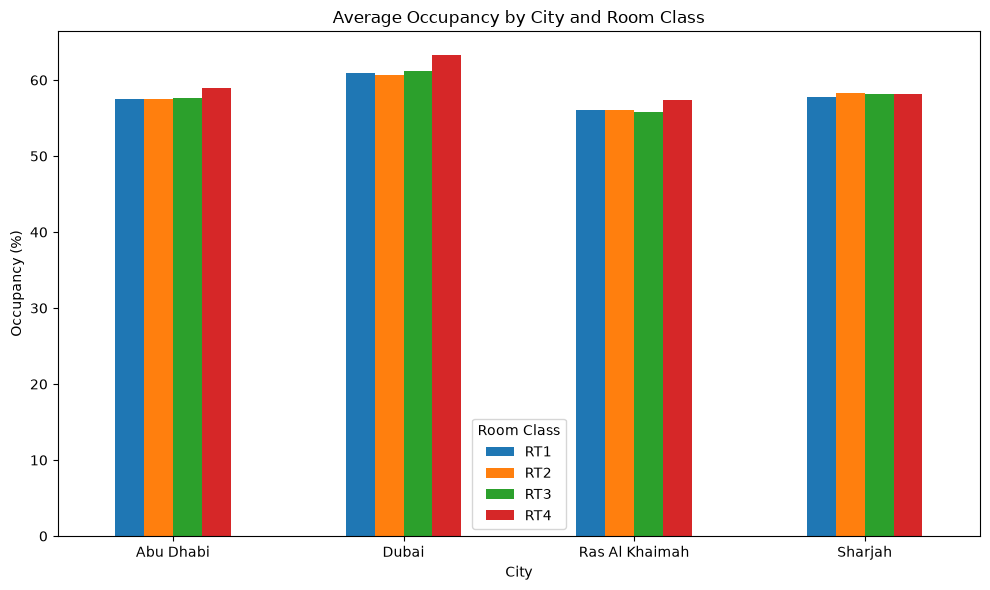

In [277]:
import matplotlib.pyplot as plt

occupancy_city_room = merged_df.groupby(
    ['city', 'room_category']
)['occupancy'].mean().unstack()

occupancy_city_room.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Occupancy by City and Room Class')
plt.xlabel('City')
plt.ylabel('Occupancy (%)')
plt.xticks(rotation=0)
plt.legend(title='Room Class')
plt.tight_layout()
plt.show()

### Dubai records the highest occupancy across room classes, while Ras Al Khaimah records the lowest, with RT4 showing the highest occupancy within each city.

### Line chart: weekly occupancy trend across the 12 weeks.

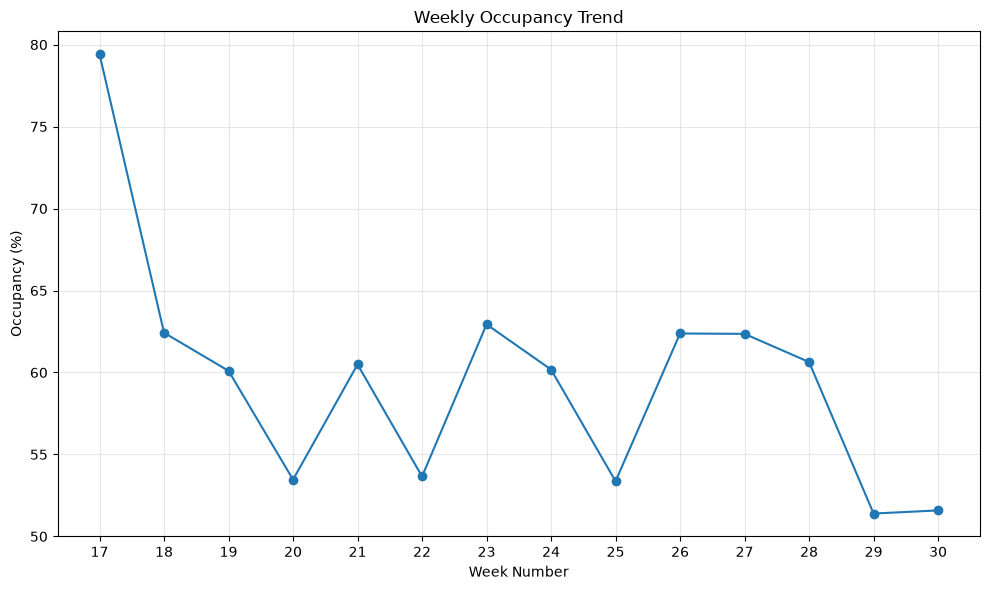

In [278]:
plt.figure(figsize=(10, 6))

plt.plot(
    weekly_occupancy.index,
    weekly_occupancy.values,
    marker='o'
)

plt.title('Weekly Occupancy Trend')
plt.xlabel('Week Number')
plt.ylabel('Occupancy (%)')
plt.xticks(weekly_occupancy.index)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Average occupancy declined from 79.41% in Week 17 to 51.59% in Week 30, indicating a substantial weakening in occupancy over the analysis period despite week-to-week fluctuations.

### Grouped bar chart: weekday versus weekend occupancy for each city

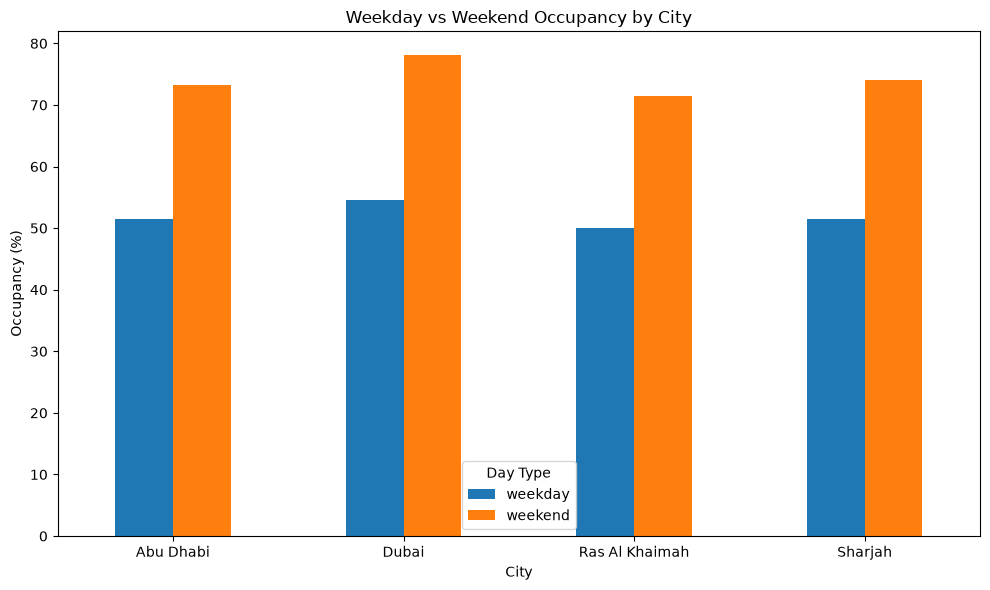

In [280]:
weekend_weekday_occupancy.unstack().plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Weekday vs Weekend Occupancy by City')
plt.xlabel('City')
plt.ylabel('Occupancy (%)')
plt.xticks(rotation=0)
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

### Weekend occupancy is consistently higher than weekday occupancy across all cities, with the gap ranging from approximately 21 to 23 percentage points.

### Horizontal bar chart: RevPAR by property, sorted.

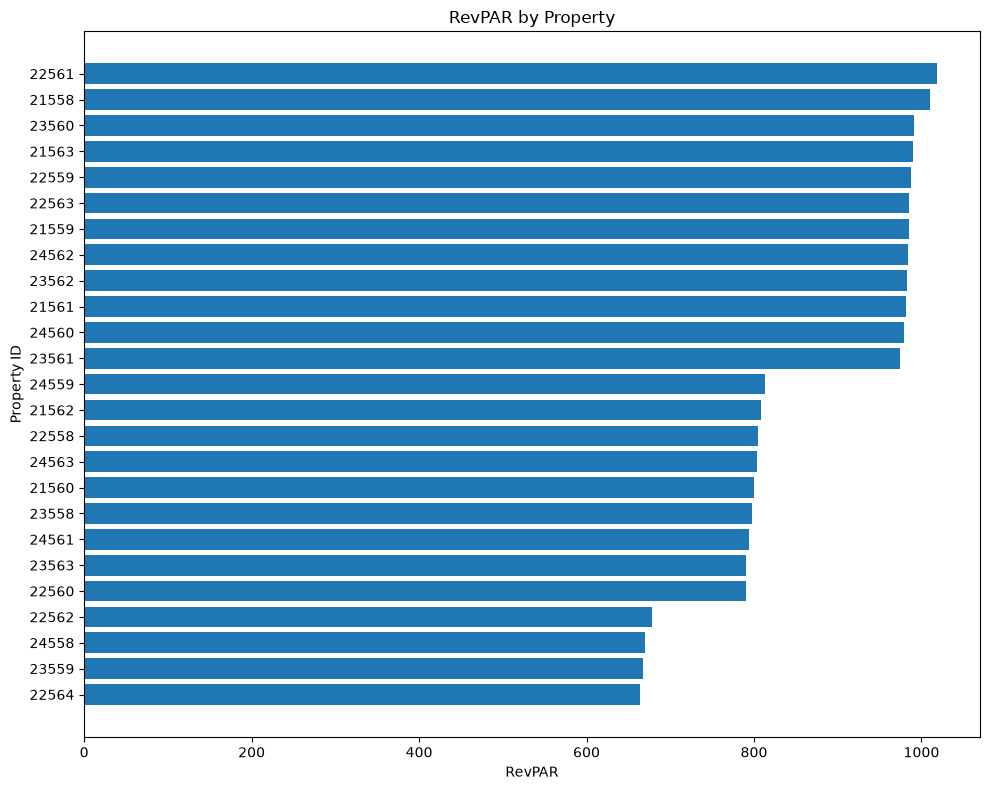

In [281]:
revpar_sorted = RevPar_by_property.sort_values()

plt.figure(figsize=(10, 8))

plt.barh(
    revpar_sorted.index.astype(str),
    revpar_sorted.values
)

plt.title('RevPAR by Property')
plt.xlabel('RevPAR')
plt.ylabel('Property ID')

plt.tight_layout()
plt.show()

### RevPAR varies substantially across properties, ranging from 664.26 to 1,018.99, highlighting meaningful differences in revenue performance across the portfolio.

### Bar chart: revenue by booking platform. Do not use a pie chart. With seven categories a pie makes the comparison harder, and comparing angles is worse than comparing bar lengths.

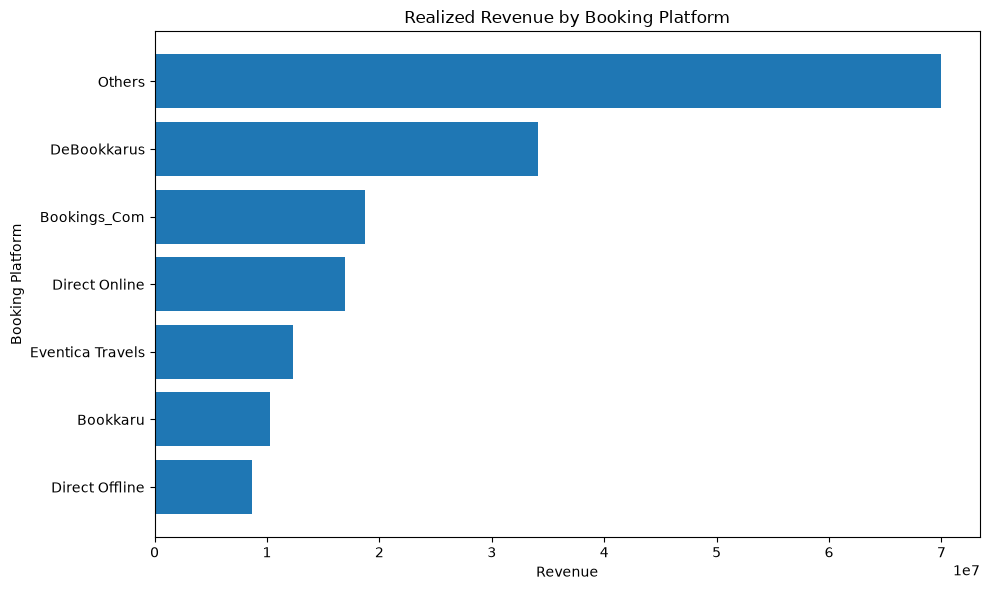

In [282]:
revenue_platform_sorted = revenue_by_platform.sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    revenue_platform_sorted.index,
    revenue_platform_sorted.values
)

plt.title('Realized Revenue by Booking Platform')
plt.xlabel('Revenue')
plt.ylabel('Booking Platform')

plt.tight_layout()
plt.show()

### The Others category generated the highest realized revenue at 69.93M, followed by DeBookkarus at 34.08M, while Direct Offline generated the lowest at 8.64M.

### Box plot: revenue_realized by hotel category, showing the spread and any remaining outliers.

<Figure size 800x600 with 0 Axes>

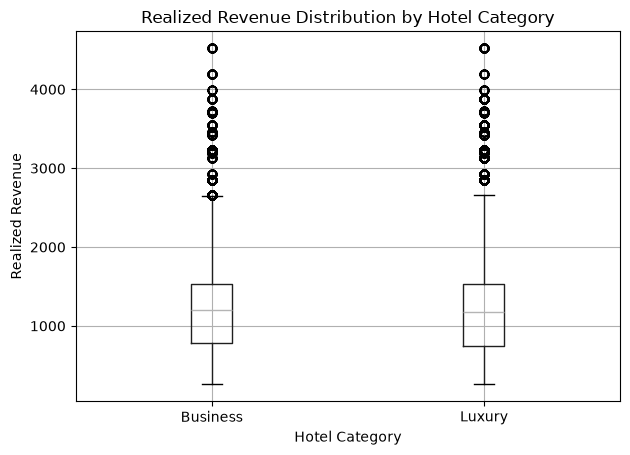

In [283]:
plt.figure(figsize=(8, 6))

booking_hotel_df.boxplot(
    column='revenue_realized',
    by='category'
)

plt.title('Realized Revenue Distribution by Hotel Category')
plt.suptitle('')
plt.xlabel('Hotel Category')
plt.ylabel('Realized Revenue')

plt.tight_layout()
plt.show()

### The box plot shows the distribution and spread of realized revenue for Luxury and Business hotels, including any remaining extreme values that may affect revenue analysis.

## Appending the August Data

In [284]:
new_data_df = pd.read_csv('new_data_august.csv')


In [285]:
new_data_df.head()

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
0,21559,365 Luxe Exotica,Luxury,Abu Dhabi,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,30,30,100.00
1,24562,365 Ocean Bay,Luxury,Ras Al Khaimah,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,21,30,70.00
2,24563,365 Majestic Palace,Business,Ras Al Khaimah,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,23,30,76.67
3,24558,365 Royal Grands,Luxury,Ras Al Khaimah,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,30,40,75.00
4,24560,365 City Haven,Business,Ras Al Khaimah,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,20,26,76.92


In [286]:
new_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          7 non-null      int64  
 1   property_name        7 non-null      str    
 2   category             7 non-null      str    
 3   city                 7 non-null      str    
 4   room_category        7 non-null      str    
 5   room_class           7 non-null      str    
 6   check_in_date        7 non-null      str    
 7   mmm yy               7 non-null      str    
 8   week no              7 non-null      str    
 9   day_type             7 non-null      str    
 10  successful_bookings  7 non-null      int64  
 11  capacity             7 non-null      int64  
 12  occ%                 7 non-null      float64
dtypes: float64(1), int64(3), str(9)
memory usage: 860.0 bytes


In [287]:
new_data_df.shape

(7, 13)

In [289]:
print("August columns:")
print(new_data_df.columns.tolist())

print("\nAggregated booking columns:")
print(aggregated_booking_df.columns.tolist())

August columns:
['property_id', 'property_name', 'category', 'city', 'room_category', 'room_class', 'check_in_date', 'mmm yy', 'week no', 'day_type', 'successful_bookings', 'capacity', 'occ%']

Aggregated booking columns:
['property_id', 'check_in_date', 'room_category', 'successful_bookings', 'capacity', 'occupancy', 'RevPAR']


In [294]:
august_columns = set(new_data_df.columns)
aggregated_columns = set(aggregated_booking_df.columns)

print("Matching columns:")
print(august_columns & aggregated_columns)

print("\n Only in August:")
print(august_columns - aggregated_columns)

print("\n Only in aggregated bookings:")
print(aggregated_columns - august_columns)

Matching columns:
{'room_category', 'property_id', 'successful_bookings', 'check_in_date', 'capacity'}

 Only in August:
{'day_type', 'room_class', 'week no', 'category', 'city', 'occ%', 'property_name', 'mmm yy'}

 Only in aggregated bookings:
{'occupancy', 'RevPAR'}


### Reshaping

In [295]:
august_aggregated = new_data_df[
    [
        'property_id',
        'check_in_date',
        'room_category',
        'successful_bookings',
        'capacity'
    ]
].copy()
august_aggregated

,property_id,check_in_date,room_category,successful_bookings,capacity
0,21559,2022-08-01,RT1,30,30
1,24562,2022-08-01,RT1,21,30
2,24563,2022-08-01,RT1,23,30
3,24558,2022-08-01,RT1,30,40
4,24560,2022-08-01,RT1,20,26
5,22561,2022-08-01,RT1,18,26
6,22564,2022-08-01,RT1,10,16


In [296]:
august_aggregated.columns

Index(['property_id', 'check_in_date', 'room_category', 'successful_bookings',
       'capacity'],
      dtype='str')

### Verification

In [299]:
august_check = pd.merge(
    new_data_df,
    dim_hotels_df[
        ['property_id', 'property_name', 'category', 'city']
    ],
    on='property_id',
    suffixes=('_august', '_dimension')
)
august_check

,property_id,property_name_august,category_august,city_august,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%,property_name_dimension,category_dimension,city_dimension
0,21559,365 Luxe Exotica,Luxury,Abu Dhabi,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,30,30,100.00,365 Luxe Exotica,Luxury,Abu Dhabi
1,24562,365 Ocean Bay,Luxury,Ras Al Khaimah,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,21,30,70.00,365 Ocean Bay,Luxury,Ras Al Khaimah
2,24563,365 Majestic Palace,Business,Ras Al Khaimah,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,23,30,76.67,365 Majestic Palace,Business,Ras Al Khaimah
3,24558,365 Royal Grands,Luxury,Ras Al Khaimah,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,30,40,75.00,365 Royal Grands,Luxury,Ras Al Khaimah
4,24560,365 City Haven,Business,Ras Al Khaimah,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,20,26,76.92,365 City Haven,Business,Ras Al Khaimah
5,22561,365 Azure Blu,Luxury,Abu Dhabi,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,18,26,69.23,365 Azure Blu,Luxury,Abu Dhabi
6,22564,365 Four Seasons,Business,Abu Dhabi,RT1,Standard,2022-08-01,Aug 22,W 32,weekday,10,16,62.50,365 Four Seasons,Business,Abu Dhabi


In [300]:
attribute_mismatches = august_check[
    (august_check['property_name_august'] != august_check['property_name_dimension']) |
    (august_check['category_august'] != august_check['category_dimension']) |
    (august_check['city_august'] != august_check['city_dimension'])
]

attribute_mismatches

,property_id,property_name_august,category_august,city_august,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%,property_name_dimension,category_dimension,city_dimension


**Attribute verification:** The duplicated property attributes in the August file were compared against `dim_hotels`. No mismatches were found, so the August property attributes are consistent with the dimension table.

In [301]:
original_rows = len(aggregated_booking_df)
original_rows

9194

In [303]:
aggregated_booking_df = pd.concat(
    [aggregated_booking_df, august_aggregated],
    ignore_index=True
)
aggregated_booking_df

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy,RevPAR
0,21559,2022-05-01,RT1,25,30.0,83.33,1243.72
1,24562,2022-05-01,RT1,28,30.0,93.33,1392.97
2,24563,2022-05-01,RT1,23,30.0,76.67,1144.32
3,21558,2022-05-01,RT1,18,19.0,94.74,1414.01
4,22560,2022-05-01,RT1,28,40.0,70.00,1044.76
...,...,...,...,...,...,...,...
9203,24563,2022-08-01,RT1,23,30.0,NaN,NaN
9204,24558,2022-08-01,RT1,30,40.0,NaN,NaN
9205,24560,2022-08-01,RT1,20,26.0,NaN,NaN
9206,22561,2022-08-01,RT1,18,26.0,NaN,NaN


In [304]:
new_rows = len(aggregated_booking_df)

print("Original rows:", original_rows)
print("August rows:", len(august_aggregated))
print("New total rows:", new_rows)
print("Rows added:", new_rows - original_rows)

Original rows: 9194
August rows: 7
New total rows: 9208
Rows added: 14


## Findings

1. Significant Weekday–Weekend Occupancy Gap: Weekend occupancy was consistently higher than weekday occupancy across all four cities, with weekend occupancy ranging from 71.46% to 78.05%, compared with 50.06% to 54.65% on weekdays. This represents a gap of approximately 21–23 percentage points, indicating substantially weaker weekday occupancy.

2. Occupancy Declined Over the Analysis Period: Average weekly occupancy declined from 79.41% in Week 17 to 51.59% in Week 30, a decrease of approximately 27.82 percentage points. Although there were fluctuations between weeks, the overall pattern indicates that occupancy weakened toward the end of the analysis period.

3. Guest Ratings Are Strongly Associated with Occupancy: Property-level average guest rating and occupancy showed a very strong positive correlation of 0.995. Properties with higher average ratings tended to have higher occupancy, making guest satisfaction an important metric to monitor alongside occupancy; however, this correlation does not establish that higher ratings directly cause higher occupancy.